In [8]:
# ============================================================
# 1. LOAD CLEAN GRAYSCALE REFERENCE IMAGE
# ============================================================

uploaded = files.upload()

filename = next(iter(uploaded))

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Error: Could not load the image.")

Saving common-zebras-savannah-2-nature-wildlife-photography-james-warwick-bw.webp to common-zebras-savannah-2-nature-wildlife-photography-james-warwick-bw (3).webp


Image loaded successfully.
Image size: (1000, 1500)

IMAGE DENOISING RESULTS

--- Gaussian Noise ---
5x5 Box Filter     | MSE: 239.7610 | PSNR: 24.33 dB
5x5 Gaussian Filter| MSE: 159.6659 | PSNR: 26.10 dB
5x5 Median Filter  | MSE: 223.6400 | PSNR: 24.64 dB

--- Salt-and-Pepper Noise ---
5x5 Box Filter     | MSE: 261.7842 | PSNR: 23.95 dB
5x5 Gaussian Filter| MSE: 193.6304 | PSNR: 25.26 dB
5x5 Median Filter  | MSE: 177.8351 | PSNR: 25.63 dB


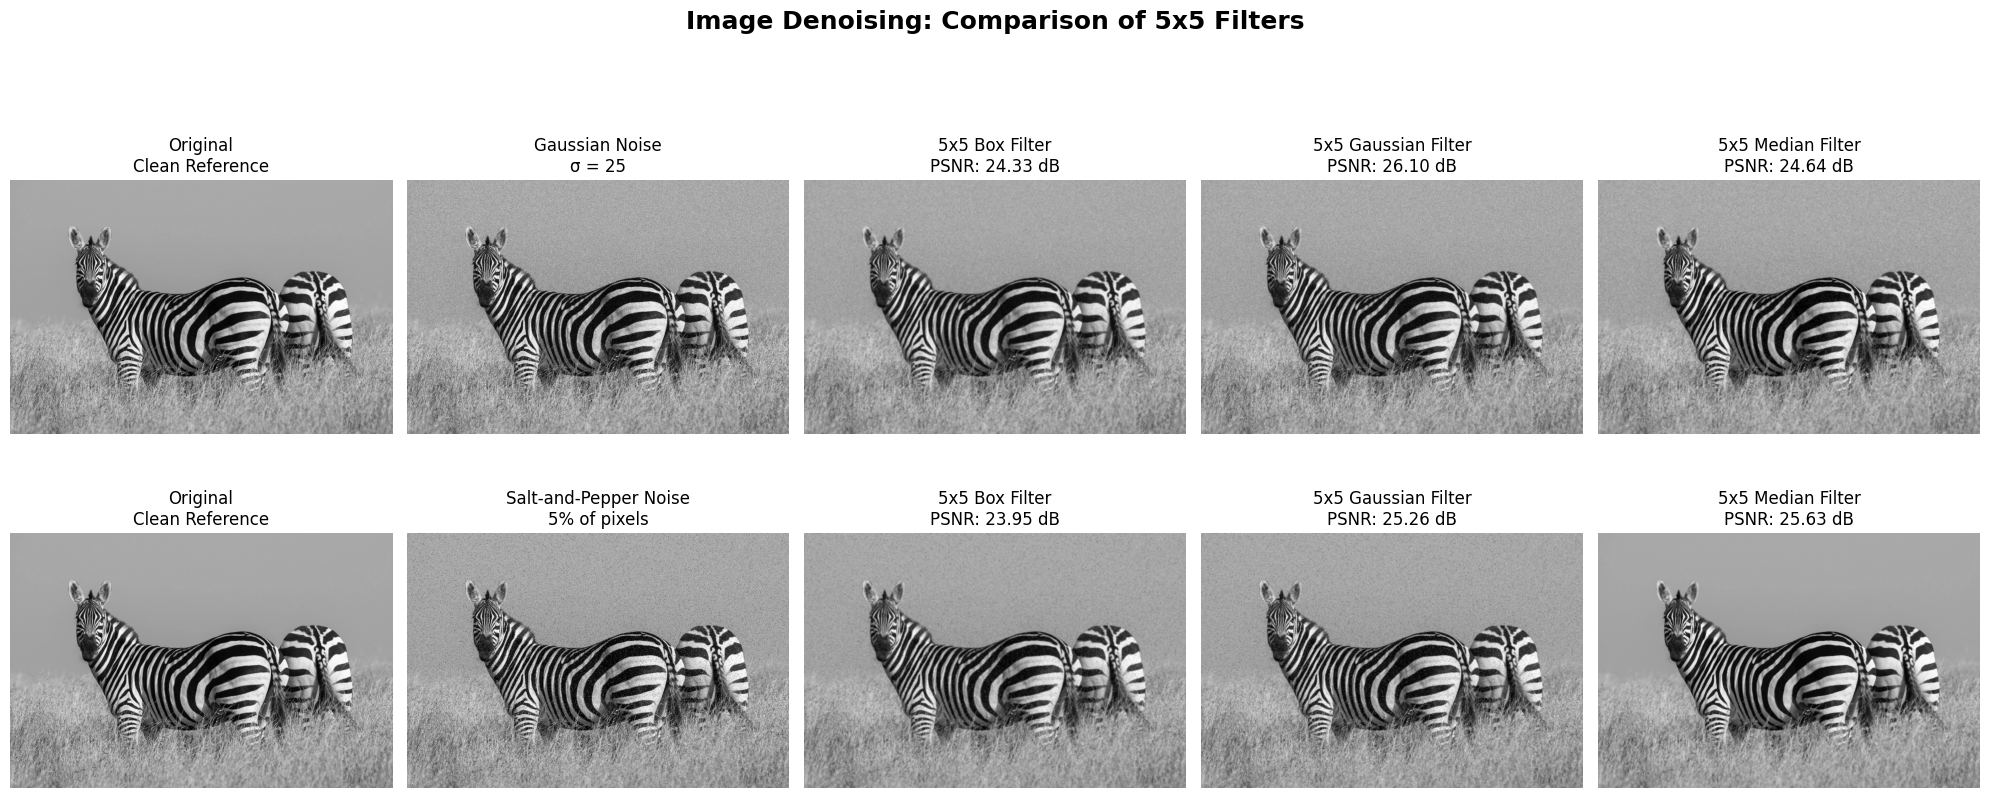

In [9]:
# ============================================================
# IMAGE DENOISING USING BOX, GAUSSIAN, AND MEDIAN FILTERS
# Google Colab
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Image loaded successfully.")
print("Image size:", img.shape)


# ============================================================
# 2. FUNCTIONS FOR MSE AND PSNR
# ============================================================

def compute_mse(original, restored):
    """Calculate Mean Squared Error (MSE)."""

    mse = np.mean(
        (original.astype(np.float64) -
         restored.astype(np.float64)) ** 2
    )

    return mse


def compute_psnr(original, restored):
    """Calculate Peak Signal-to-Noise Ratio (PSNR)."""

    mse = compute_mse(original, restored)

    if mse == 0:
        return float('inf')

    max_pixel = 255.0

    psnr = 10 * np.log10(
        (max_pixel ** 2) / mse
    )

    return psnr


# ============================================================
# 3. GENERATE GAUSSIAN NOISE
# ============================================================
# Zero mean = 0
# Standard deviation = 25

mean = 0
std_dev = 25

gaussian_noise = np.random.normal(
    mean,
    std_dev,
    img.shape
).astype(np.float32)

img_gaussian = np.clip(
    img.astype(np.float32) + gaussian_noise,
    0,
    255
).astype(np.uint8)


# ============================================================
# 4. GENERATE SALT-AND-PEPPER (IMPULSE) NOISE
# ============================================================
# 5% of total image pixels

noise_probability = 0.05

img_sp = img.copy()

num_pixels = img.size

num_noisy_pixels = int(
    noise_probability * num_pixels
)

# Half salt, half pepper
num_salt = num_noisy_pixels // 2
num_pepper = num_noisy_pixels - num_salt


# ---- Salt Noise (255) ----

salt_coords = [
    np.random.randint(
        0,
        dimension,
        num_salt
    )
    for dimension in img.shape
]

img_sp[tuple(salt_coords)] = 255


# ---- Pepper Noise (0) ----

pepper_coords = [
    np.random.randint(
        0,
        dimension,
        num_pepper
    )
    for dimension in img.shape
]

img_sp[tuple(pepper_coords)] = 0


# ============================================================
# 5. APPLY 5x5 FILTERS TO GAUSSIAN-NOISY IMAGE
# ============================================================

# 5x5 Box Filter
gaussian_box = cv2.blur(
    img_gaussian,
    (5, 5)
)

# 5x5 Gaussian Filter, sigmaX = 0
gaussian_filtered = cv2.GaussianBlur(
    img_gaussian,
    (5, 5),
    0
)

# 5x5 Median Filter
gaussian_median = cv2.medianBlur(
    img_gaussian,
    5
)


# ============================================================
# 6. APPLY 5x5 FILTERS TO SALT-AND-PEPPER IMAGE
# ============================================================

# 5x5 Box Filter
sp_box = cv2.blur(
    img_sp,
    (5, 5)
)

# 5x5 Gaussian Filter, sigmaX = 0
sp_gaussian = cv2.GaussianBlur(
    img_sp,
    (5, 5),
    0
)

# 5x5 Median Filter
sp_median = cv2.medianBlur(
    img_sp,
    5
)


# ============================================================
# 7. CALCULATE MSE AND PSNR
# ============================================================

# ----- Gaussian Noise -----

mse_gaussian_box = compute_mse(
    img,
    gaussian_box
)

psnr_gaussian_box = compute_psnr(
    img,
    gaussian_box
)


mse_gaussian_filtered = compute_mse(
    img,
    gaussian_filtered
)

psnr_gaussian_filtered = compute_psnr(
    img,
    gaussian_filtered
)


mse_gaussian_median = compute_mse(
    img,
    gaussian_median
)

psnr_gaussian_median = compute_psnr(
    img,
    gaussian_median
)


# ----- Salt-and-Pepper Noise -----

mse_sp_box = compute_mse(
    img,
    sp_box
)

psnr_sp_box = compute_psnr(
    img,
    sp_box
)


mse_sp_gaussian = compute_mse(
    img,
    sp_gaussian
)

psnr_sp_gaussian = compute_psnr(
    img,
    sp_gaussian
)


mse_sp_median = compute_mse(
    img,
    sp_median
)

psnr_sp_median = compute_psnr(
    img,
    sp_median
)


# ============================================================
# 8. PRINT MSE AND PSNR RESULTS
# ============================================================

print("\n" + "=" * 60)
print("IMAGE DENOISING RESULTS")
print("=" * 60)

print("\n--- Gaussian Noise ---")

print(
    f"5x5 Box Filter     | "
    f"MSE: {mse_gaussian_box:.4f} | "
    f"PSNR: {psnr_gaussian_box:.2f} dB"
)

print(
    f"5x5 Gaussian Filter| "
    f"MSE: {mse_gaussian_filtered:.4f} | "
    f"PSNR: {psnr_gaussian_filtered:.2f} dB"
)

print(
    f"5x5 Median Filter  | "
    f"MSE: {mse_gaussian_median:.4f} | "
    f"PSNR: {psnr_gaussian_median:.2f} dB"
)


print("\n--- Salt-and-Pepper Noise ---")

print(
    f"5x5 Box Filter     | "
    f"MSE: {mse_sp_box:.4f} | "
    f"PSNR: {psnr_sp_box:.2f} dB"
)

print(
    f"5x5 Gaussian Filter| "
    f"MSE: {mse_sp_gaussian:.4f} | "
    f"PSNR: {psnr_sp_gaussian:.2f} dB"
)

print(
    f"5x5 Median Filter  | "
    f"MSE: {mse_sp_median:.4f} | "
    f"PSNR: {psnr_sp_median:.2f} dB"
)

print("=" * 60)


# ============================================================
# 9. CONSTRUCT MATPLOTLIB SUBPLOT GRID
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 9)
)


# ============================================================
# ROW 1 — GAUSSIAN NOISE
# ============================================================

# Original
axes[0, 0].imshow(
    img,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[0, 0].set_title(
    "Original\nClean Reference"
)


# Gaussian noisy
axes[0, 1].imshow(
    img_gaussian,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[0, 1].set_title(
    "Gaussian Noise\n"
    f"σ = {std_dev}"
)


# Box Filter
axes[0, 2].imshow(
    gaussian_box,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[0, 2].set_title(
    "5x5 Box Filter\n"
    f"PSNR: {psnr_gaussian_box:.2f} dB"
)


# Gaussian Filter
axes[0, 3].imshow(
    gaussian_filtered,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[0, 3].set_title(
    "5x5 Gaussian Filter\n"
    f"PSNR: {psnr_gaussian_filtered:.2f} dB"
)


# Median Filter
axes[0, 4].imshow(
    gaussian_median,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[0, 4].set_title(
    "5x5 Median Filter\n"
    f"PSNR: {psnr_gaussian_median:.2f} dB"
)


# ============================================================
# ROW 2 — SALT-AND-PEPPER NOISE
# ============================================================

# Original
axes[1, 0].imshow(
    img,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[1, 0].set_title(
    "Original\nClean Reference"
)


# Salt-and-pepper noisy
axes[1, 1].imshow(
    img_sp,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[1, 1].set_title(
    "Salt-and-Pepper Noise\n"
    f"{noise_probability * 100:.0f}% of pixels"
)


# Box Filter
axes[1, 2].imshow(
    sp_box,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[1, 2].set_title(
    "5x5 Box Filter\n"
    f"PSNR: {psnr_sp_box:.2f} dB"
)


# Gaussian Filter
axes[1, 3].imshow(
    sp_gaussian,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[1, 3].set_title(
    "5x5 Gaussian Filter\n"
    f"PSNR: {psnr_sp_gaussian:.2f} dB"
)


# Median Filter
axes[1, 4].imshow(
    sp_median,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[1, 4].set_title(
    "5x5 Median Filter\n"
    f"PSNR: {psnr_sp_median:.2f} dB"
)


# ============================================================
# 10. FORMAT AND DISPLAY PLOT
# ============================================================

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle(
    "Image Denoising: Comparison of 5x5 Filters",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()


/tmp/ipykernel_1800/3172760208.py:82: RuntimeWarning: divide by zero encountered in divide
  (D1 - D0) * D /


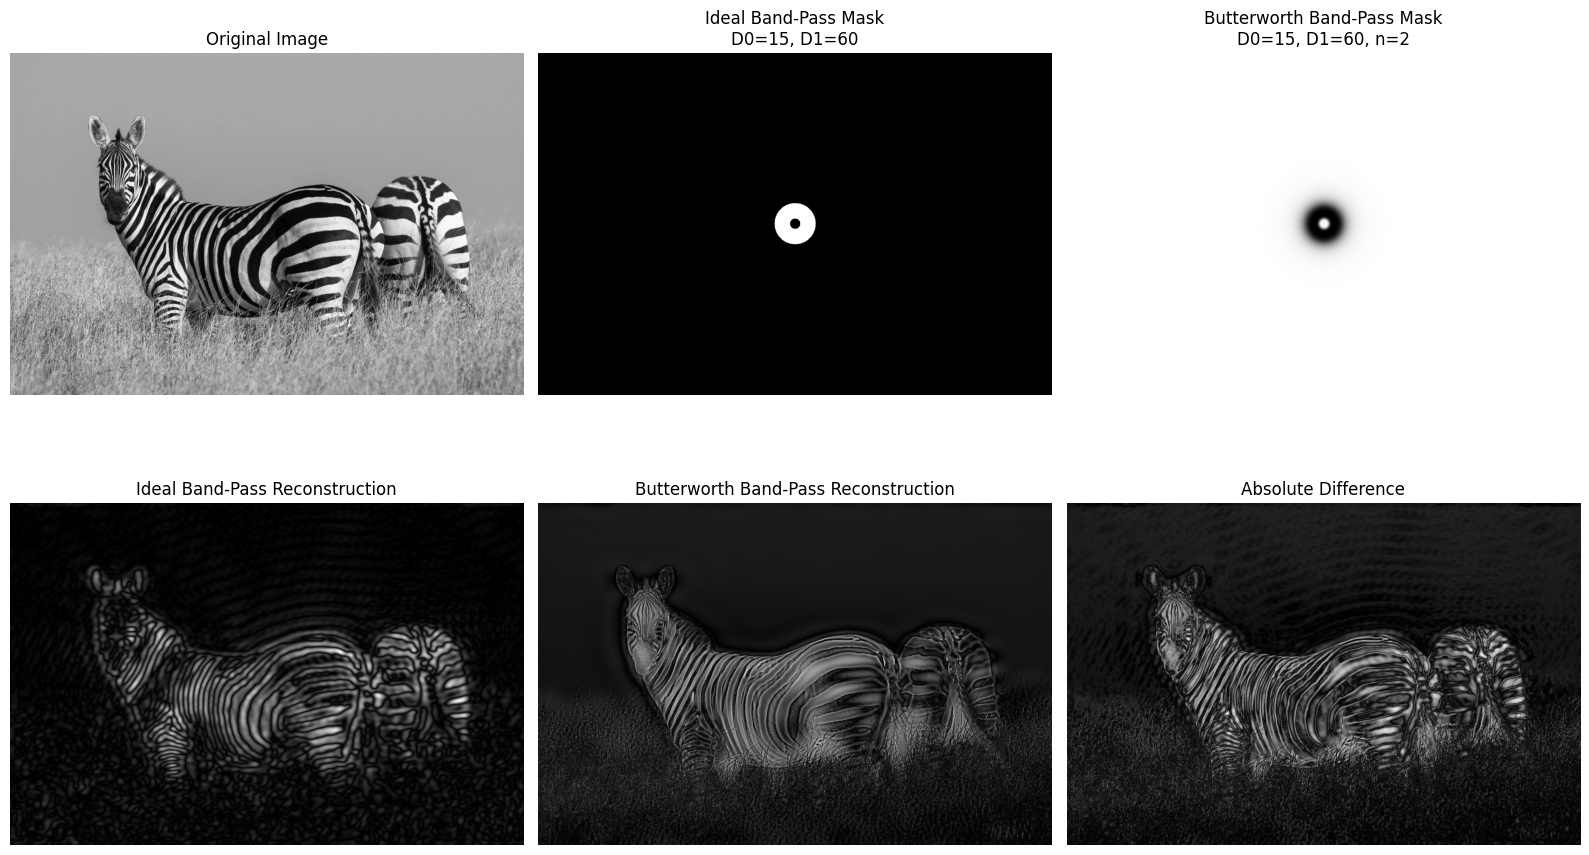

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load grayscale image and compute centered DFT
# ============================================================

dft = cv2.dft(
    np.float32(img),
    flags=cv2.DFT_COMPLEX_OUTPUT
)

# Shift zero-frequency component to the center
dft_shift = np.fft.fftshift(dft)

rows, cols = img.shape
crow, ccol = rows // 2, cols // 2


# ============================================================
# 2. Create Euclidean distance grid D(u,v)
# ============================================================

y, x = np.ogrid[
    -crow:rows-crow,
    -ccol:cols-ccol
]

d_matrix = np.sqrt(x**2 + y**2)


# ============================================================
# 3. Define Band-Pass Cutoffs and Butterworth Order
# ============================================================

D0 = 15       # Inner cutoff radius
D1 = 60       # Outer cutoff radius
n = 2         # Butterworth filter order


# ============================================================
# 4. Create Ideal Band-Pass Filter
# ============================================================

mask_ideal = np.zeros(
    (rows, cols, 2),
    np.float32
)

band_indices = (
    (d_matrix >= D0) &
    (d_matrix <= D1)
)

mask_ideal[band_indices] = 1.0


# ============================================================
# 5. Create Butterworth Band-Pass Filter
# ============================================================

# Butterworth band-pass formulation:
#
# H(u,v) =
# 1 / [1 + ((D1-D0)*D / (D^2-D0*D1))^(2n)]
#
# where:
# D0 = lower cutoff
# D1 = upper cutoff
# n  = filter order

# Avoid division by zero at the center
epsilon = 1e-8

D = d_matrix.copy()
D[D == 0] = epsilon

butterworth_2d = 1 / (
    1 +
    (
        (D1 - D0) * D /
        (D**2 - D0 * D1)
    ) ** (2 * n)
)

# Set the DC component to zero
butterworth_2d[d_matrix == 0] = 0

# Convert to 2-channel mask
mask_butterworth = np.zeros(
    (rows, cols, 2),
    np.float32
)

mask_butterworth[:, :, 0] = butterworth_2d
mask_butterworth[:, :, 1] = butterworth_2d


# ============================================================
# 6. Apply Ideal Band-Pass Filter
# ============================================================

fshift_ideal = dft_shift * mask_ideal

# Shift frequency spectrum back
f_ishift_ideal = np.fft.ifftshift(
    fshift_ideal
)

# Inverse DFT
img_back_ideal = cv2.idft(
    f_ishift_ideal
)

# Spatial magnitude
img_reconstructed_ideal = cv2.magnitude(
    img_back_ideal[:, :, 0],
    img_back_ideal[:, :, 1]
)


# ============================================================
# 7. Apply Butterworth Band-Pass Filter
# ============================================================

fshift_butterworth = (
    dft_shift * mask_butterworth
)

# Shift back
f_ishift_butterworth = np.fft.ifftshift(
    fshift_butterworth
)

# Inverse DFT
img_back_butterworth = cv2.idft(
    f_ishift_butterworth
)

# Spatial magnitude
img_reconstructed_butterworth = cv2.magnitude(
    img_back_butterworth[:, :, 0],
    img_back_butterworth[:, :, 1]
)


# ============================================================
# 8. Normalize Reconstructed Images for Display
# ============================================================

ideal_display = cv2.normalize(
    img_reconstructed_ideal,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

butterworth_display = cv2.normalize(
    img_reconstructed_butterworth,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


# ============================================================
# 9. Display Results
# ============================================================

plt.figure(figsize=(16, 10))


# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')


# Ideal mask
plt.subplot(2, 3, 2)
plt.imshow(mask_ideal[:, :, 0], cmap='gray')
plt.title(
    f"Ideal Band-Pass Mask\n"
    f"D0={D0}, D1={D1}"
)
plt.axis('off')


# Butterworth mask
plt.subplot(2, 3, 3)
plt.imshow(
    mask_butterworth[:, :, 0],
    cmap='gray'
)
plt.title(
    f"Butterworth Band-Pass Mask\n"
    f"D0={D0}, D1={D1}, n={n}"
)
plt.axis('off')


# Ideal reconstruction
plt.subplot(2, 3, 4)
plt.imshow(
    ideal_display,
    cmap='gray'
)
plt.title(
    "Ideal Band-Pass Reconstruction"
)
plt.axis('off')


# Butterworth reconstruction
plt.subplot(2, 3, 5)
plt.imshow(
    butterworth_display,
    cmap='gray'
)
plt.title(
    "Butterworth Band-Pass Reconstruction"
)
plt.axis('off')


# Difference between outputs
difference = cv2.absdiff(
    ideal_display,
    butterworth_display
)

plt.subplot(2, 3, 6)
plt.imshow(
    difference,
    cmap='gray'
)
plt.title(
    "Absolute Difference"
)
plt.axis('off')


plt.tight_layout()
plt.show()


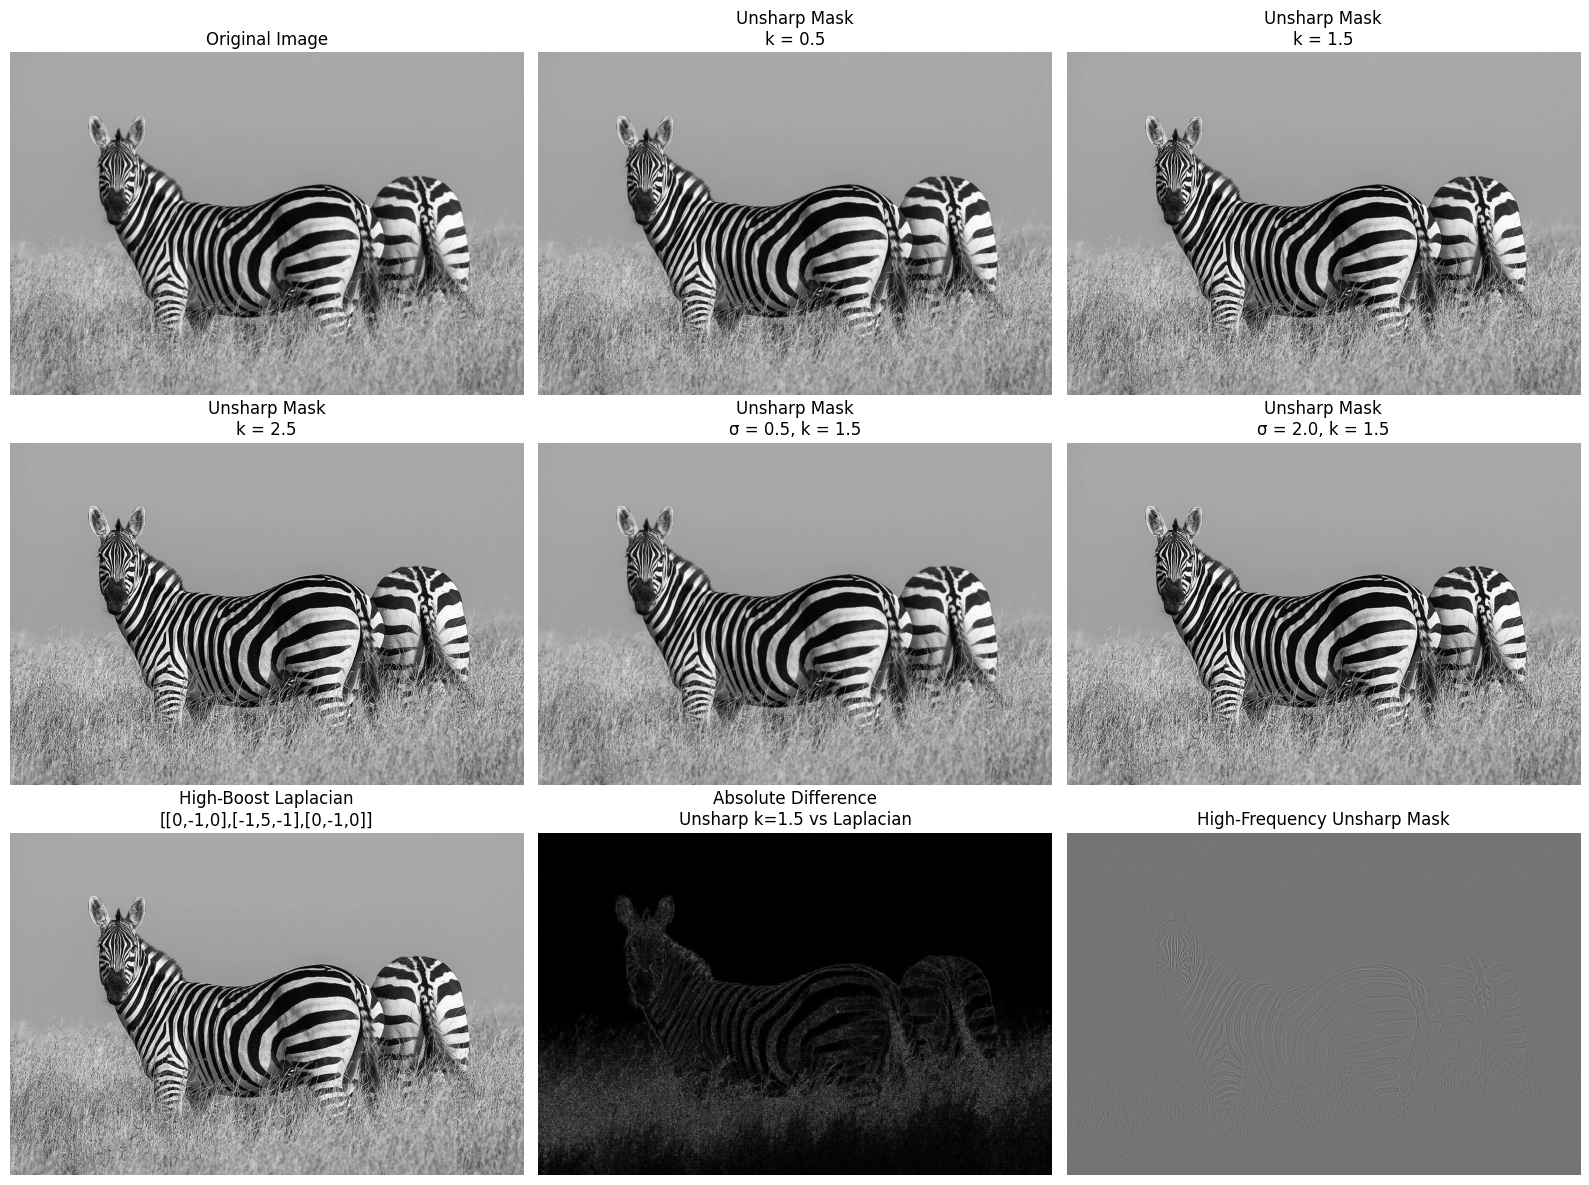

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Custom Unsharp Masking Function
# ============================================================

def unsharp_mask(img, kernel_size=(5, 5), sigma=1.0, k=1.5):
    """
    Applies custom Unsharp Masking enhancement.

    Parameters:
        img          : Grayscale input image
        kernel_size  : Gaussian blur kernel size
        sigma        : Gaussian standard deviation
        k            : High-frequency amplification factor
    """

    # 1. Smooth signal with Gaussian low-pass filter
    blurred = cv2.GaussianBlur(
        img,
        kernel_size,
        sigma
    )

    # 2. Isolate high-frequency components
    mask = (
        img.astype(np.float32)
        - blurred.astype(np.float32)
    )

    # 3. Add scaled high-frequency mask
    sharpened = (
        img.astype(np.float32)
        + k * mask
    )

    # 4. Clip values and convert back to uint8
    sharpened = np.clip(
        sharpened,
        0,
        255
    ).astype(np.uint8)

    return sharpened

# ============================================================
# 3. Evaluate Different High-Boost Factors
# ============================================================

sharpened_k05 = unsharp_mask(
    img,
    kernel_size=(5, 5),
    sigma=1.0,
    k=0.5
)

sharpened_k15 = unsharp_mask(
    img,
    kernel_size=(5, 5),
    sigma=1.0,
    k=1.5
)

sharpened_k25 = unsharp_mask(
    img,
    kernel_size=(5, 5),
    sigma=1.0,
    k=2.5
)


# ============================================================
# 4. Evaluate Different Gaussian Blur Scales
# ============================================================

sharpened_sigma05 = unsharp_mask(
    img,
    kernel_size=(5, 5),
    sigma=0.5,
    k=1.5
)

sharpened_sigma20 = unsharp_mask(
    img,
    kernel_size=(5, 5),
    sigma=2.0,
    k=1.5
)


# ============================================================
# 5. High-Boost Laplacian Kernel
# ============================================================

laplacian_kernel = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
], dtype=np.float32)


# ============================================================
# 6. Apply Laplacian High-Boost Filter
# ============================================================

laplacian_sharpened = cv2.filter2D(
    img,
    ddepth=-1,
    kernel=laplacian_kernel
)


# ============================================================
# 7. Display Results
# ============================================================

plt.figure(figsize=(16, 12))


# Original
plt.subplot(3, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')


# k = 0.5
plt.subplot(3, 3, 2)
plt.imshow(sharpened_k05, cmap='gray')
plt.title("Unsharp Mask\nk = 0.5")
plt.axis('off')


# k = 1.5
plt.subplot(3, 3, 3)
plt.imshow(sharpened_k15, cmap='gray')
plt.title("Unsharp Mask\nk = 1.5")
plt.axis('off')


# k = 2.5
plt.subplot(3, 3, 4)
plt.imshow(sharpened_k25, cmap='gray')
plt.title("Unsharp Mask\nk = 2.5")
plt.axis('off')


# Sigma = 0.5
plt.subplot(3, 3, 5)
plt.imshow(sharpened_sigma05, cmap='gray')
plt.title("Unsharp Mask\nσ = 0.5, k = 1.5")
plt.axis('off')


# Sigma = 2.0
plt.subplot(3, 3, 6)
plt.imshow(sharpened_sigma20, cmap='gray')
plt.title("Unsharp Mask\nσ = 2.0, k = 1.5")
plt.axis('off')


# Laplacian
plt.subplot(3, 3, 7)
plt.imshow(laplacian_sharpened, cmap='gray')
plt.title(
    "High-Boost Laplacian\n"
    "[[0,-1,0],[-1,5,-1],[0,-1,0]]"
)
plt.axis('off')


# Difference: Unsharp vs Laplacian
difference = cv2.absdiff(
    sharpened_k15,
    laplacian_sharpened
)

plt.subplot(3, 3, 8)
plt.imshow(difference, cmap='gray')
plt.title(
    "Absolute Difference\n"
    "Unsharp k=1.5 vs Laplacian"
)
plt.axis('off')


# High-frequency mask
blurred = cv2.GaussianBlur(
    img,
    (5, 5),
    1.0
)

mask = (
    img.astype(np.float32)
    - blurred.astype(np.float32)
)

mask_display = cv2.normalize(
    mask,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.subplot(3, 3, 9)
plt.imshow(mask_display, cmap='gray')
plt.title("High-Frequency Unsharp Mask")
plt.axis('off')


plt.tight_layout()
plt.show()